# Week 2.3: Embeddings Deep Dive

## Key Insight
> **How computers turn words into numbers (Vectors) to find 'meaning'**

## Learning Objectives
By the end of this notebook, you will:
- Word2Vec and GloVe internals
- Building embeddings from scratch
- Semantic similarity and vector operations
- Dimensionality reduction and visualization
- Using pre-trained embeddings

## Exercises
This notebook contains 5 exercises ranging from easy to advanced.

## Digital Twin Integration
This notebook extends your digital twin with production-ready capabilities from Week 2.

In [ ]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any, Tuple
import re
import json

print('✅ Week 2.3: Embeddings Deep Dive - Ready to start!')
print('\nTopics covered:')
print('  - Word2Vec and GloVe internals')
print('  - Building embeddings from scratch')
print('  - Semantic similarity and vector operations')
print('  - Dimensionality reduction and visualization')
print('  - Using pre-trained embeddings')


---
## Part 1: Introduction to Word2Vec and GloVe internals

Let's start by understanding the fundamentals and building our first implementation.

In [ ]:
# Example implementation
# This is a starter template - expand with your implementation

class ExampleClass:
    """
    Example class for Word2Vec and GloVe internals.
    """

    def __init__(self):
        self.data = []

    def process(self, input_data):
        """
        Process the input data.
        """
        # Add your implementation here
        return input_data

# Test the class
example = ExampleClass()
result = example.process('test data')
print(f'Result: {result}')

### 🎯 Exercise 1 (Easy): Getting Started

**Task**: Implement a basic version of the concept introduced above.

**Requirements**:
1. Follow the pattern shown in the example
2. Test your implementation with sample data
3. Verify the output matches expectations
4. Add error handling for edge cases

In [ ]:
# YOUR CODE HERE
# Complete the exercise following the instructions above

# Test your implementation
# Add test cases here

pass  # Replace with your implementation

---
## Part 2: Building embeddings from scratch

Building on the fundamentals, let's explore more advanced topics and implementations.

In [ ]:
# Advanced implementation example

def advanced_function(data: List[Any], **kwargs) -> Dict[str, Any]:
    """
    Advanced function for Building embeddings from scratch.

    Args:
        data: Input data to process
        **kwargs: Additional parameters

    Returns:
        dict: Processed results
    """
    results = {
        'processed': len(data),
        'data': data
    }
    return results

# Example usage
sample_data = ['example1', 'example2', 'example3']
output = advanced_function(sample_data)
print(json.dumps(output, indent=2))

### 🎯 Exercise 2 (Intermediate): Building on the Basics

**Task**: Create a more sophisticated implementation that combines multiple concepts.

**Requirements**:
1. Use the patterns from Part 1 and Part 2
2. Add parameter validation
3. Include helpful error messages
4. Test with various input types

In [4]:
# Small corpus — enough to learn meaningful relationships
corpus = [
    "the king rules the kingdom with wisdom",
    "the queen rules beside the king",
    "the man works in the kingdom",
    "the woman works beside the man",
    "the king and queen live in the castle",
    "the prince is the son of the king",
    "the princess is the daughter of the queen",
    "the apple grows on the tree",
    "the orange grows on the tree",
    "the apple and orange are fruits",
    "the dog runs in the park",
    "the cat sleeps in the house",
    "the dog and cat are animals",
    "the king loves the queen",
    "the man loves the woman",
]

# Quick sanity check
print(f"Corpus: {len(corpus)} sentences")
print(f"Total words: {sum(len(s.split()) for s in corpus)}")

Corpus: 15 sentences
Total words: 95


In [5]:
import numpy as np
import re
from collections import Counter, defaultdict
from typing import List, Dict, Tuple, Optional


STOP_WORDS = {"the", "a", "an", "is", "are", "was", "were", "in", "on",
              "of", "and", "or", "with", "beside", "to", "for", "at", "by"}


def clean_corpus(corpus: List[str], remove_stopwords: bool = True) -> List[List[str]]:
    """Tokenize and clean a corpus into a list of word lists."""
    if not isinstance(corpus, (list, tuple)):
        raise TypeError(f"corpus must be list, got {type(corpus).__name__}")

    cleaned = []
    for i, sentence in enumerate(corpus):
        if not isinstance(sentence, str):
            raise TypeError(f"corpus[{i}] must be str, got {type(sentence).__name__}")
        tokens = re.findall(r"[a-z]+", sentence.lower())
        if remove_stopwords:
            tokens = [t for t in tokens if t not in STOP_WORDS]
        if tokens:
            cleaned.append(tokens)
    return cleaned


class EmbeddingTrainer:
    """
    Train word embeddings from scratch using two methods:

        - Word2Vec (Skip-gram with negative sampling)
        - GloVe-lite (co-occurrence matrix + truncated SVD)

    Both methods return a dict: word → np.ndarray of shape (dim,).
    """

    def __init__(self, dim: int = 32, window: int = 2, seed: int = 42):
        # --- Validation ---
        if not isinstance(dim, int) or dim <= 0:
            raise ValueError(f"dim must be a positive int, got {dim!r}")
        if not isinstance(window, int) or window <= 0:
            raise ValueError(f"window must be a positive int, got {window!r}")

        self.dim = dim
        self.window = window
        self.seed = seed
        self.vocab: List[str] = []
        self.word2idx: Dict[str, int] = {}
        self.embeddings: Optional[Dict[str, np.ndarray]] = None

    # ----------------------------------------------------------
    # Shared preprocessing
    # ----------------------------------------------------------
    def _build_vocab(self, sentences: List[List[str]]):
        counts = Counter(w for s in sentences for w in s)
        self.vocab = sorted(counts.keys())
        self.word2idx = {w: i for i, w in enumerate(self.vocab)}
        print(f"  Vocab size: {len(self.vocab)}")

    def _extract_pairs(self, sentences):
        """Yield (center, context) pairs within the window."""
        for sentence in sentences:
            for i, center in enumerate(sentence):
                start = max(0, i - self.window)
                end = min(len(sentence), i + self.window + 1)
                for j in range(start, end):
                    if i != j:
                        yield center, sentence[j]

    # ----------------------------------------------------------
    # Method 1: Word2Vec (Skip-gram + negative sampling)
    # ----------------------------------------------------------
    def train_word2vec(self, sentences: List[List[str]],
                       epochs: int = 30, lr: float = 0.05,
                       n_negatives: int = 3) -> Dict[str, np.ndarray]:
        """
        Skip-gram: given a center word, predict context words.
        Uses negative sampling to keep training tractable.
        """
        self._build_vocab(sentences)
        V = len(self.vocab)
        rng = np.random.default_rng(self.seed)

        # Two matrices: W_in (center) and W_out (context)
        W_in = (rng.random((V, self.dim)) - 0.5) / self.dim
        W_out = np.zeros((V, self.dim))

        # Sample distribution for negatives (unigram^0.75)
        counts = np.array([sum(1 for s in sentences for w in s if w == v)
                           for v in self.vocab], dtype=float)
        probs = counts ** 0.75
        probs /= probs.sum()

        pairs = list(self._extract_pairs(sentences))
        print(f"  Training pairs: {len(pairs)}")

        def sigmoid(x):
            return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

        for epoch in range(epochs):
            rng.shuffle(pairs)
            total_loss = 0.0

            for center, context in pairs:
                ci = self.word2idx[center]
                oi = self.word2idx[context]

                # --- Positive sample ---
                v_c = W_in[ci]
                u_o = W_out[oi]
                score = sigmoid(v_c @ u_o)
                loss = -np.log(score + 1e-9)
                total_loss += loss

                grad = (score - 1.0) * lr
                W_in[ci] -= grad * u_o
                W_out[oi] -= grad * v_c

                # --- Negative samples ---
                negs = rng.choice(V, size=n_negatives, p=probs)
                for ni in negs:
                    if ni == oi:
                        continue
                    u_n = W_out[ni]
                    score_n = sigmoid(v_c @ u_n)
                    total_loss += -np.log(1.0 - score_n + 1e-9)
                    grad_n = score_n * lr
                    W_in[ci] -= grad_n * u_n
                    W_out[ni] -= grad_n * v_c

            if epoch % 5 == 0 or epoch == epochs - 1:
                print(f"  Epoch {epoch:3d} | loss {total_loss/len(pairs):.4f}")

        # L2-normalize for stable cosine similarity
        norms = np.linalg.norm(W_in, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        W_in = W_in / norms

        self.embeddings = {w: W_in[i] for w, i in self.word2idx.items()}
        return self.embeddings

    # ----------------------------------------------------------
    # Method 2: GloVe-lite (co-occurrence + SVD)
    # ----------------------------------------------------------
    def train_glove_lite(self, sentences: List[List[str]]) -> Dict[str, np.ndarray]:
        """
        Build a word-word co-occurrence matrix, apply log scaling,
        then factorize it with truncated SVD.
        """
        if not self.vocab:
            self._build_vocab(sentences)
        V = len(self.vocab)

        # Build co-occurrence matrix
        cooc = np.zeros((V, V), dtype=float)
        for center, context in self._extract_pairs(sentences):
            i = self.word2idx[center]
            j = self.word2idx[context]
            cooc[i, j] += 1.0

        print(f"  Co-occurrence matrix: {cooc.shape}, "
              f"non-zero entries: {np.count_nonzero(cooc)}")

        # Log scaling (GloVe-style): log(1 + x)
        M = np.log1p(cooc)

        # Truncated SVD
        U, S, _ = np.linalg.svd(M, full_matrices=False)
        k = min(self.dim, len(S))
        emb = U[:, :k] * np.sqrt(S[:k])  # weight by singular values

        # L2-normalize
        norms = np.linalg.norm(emb, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        emb = emb / norms

        self.embeddings = {w: emb[i] for w, i in self.word2idx.items()}
        return self.embeddings

    # ----------------------------------------------------------
    # Post-training analysis
    # ----------------------------------------------------------
    def similarity(self, w1: str, w2: str) -> float:
        self._check_ready()
        if w1 not in self.embeddings:
            raise KeyError(f"'{w1}' not in vocabulary")
        if w2 not in self.embeddings:
            raise KeyError(f"'{w2}' not in vocabulary")
        v1, v2 = self.embeddings[w1], self.embeddings[w2]
        return float(np.dot(v1, v2))  # already L2-normalized

    def nearest(self, word: str, k: int = 3) -> List[Tuple[str, float]]:
        self._check_ready()
        if word not in self.embeddings:
            raise KeyError(f"'{word}' not in vocabulary")
        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be positive int, got {k!r}")

        target = self.embeddings[word]
        scored = [(w, float(np.dot(target, v)))
                  for w, v in self.embeddings.items() if w != word]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]

    def analogy(self, a: str, b: str, c: str, k: int = 3):
        """a is to b as c is to ?  →  solve b - a + c."""
        self._check_ready()
        for w in (a, b, c):
            if w not in self.embeddings:
                raise KeyError(f"'{w}' not in vocabulary")
        target = self.embeddings[b] - self.embeddings[a] + self.embeddings[c]
        scored = [(w, float(np.dot(target, v)))
                  for w, v in self.embeddings.items() if w not in (a, b, c)]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]

    def _check_ready(self):
        if self.embeddings is None:
            raise RuntimeError("Model not trained yet. Call train_*() first.")

In [6]:
np.random.seed(42)

# Clean the corpus
sentences = clean_corpus(corpus, remove_stopwords=True)
print("Sample cleaned sentence:", sentences[0])
print()

# --- Train Word2Vec ---
print("=" * 50)
print("Word2Vec (Skip-gram + negative sampling)")
print("=" * 50)
w2v = EmbeddingTrainer(dim=32, window=2, seed=42)
w2v.train_word2vec(sentences, epochs=30, lr=0.05, n_negatives=3)
print()

# --- Test similarity ---
print("Word2Vec similarities:")
for a, b in [("king", "queen"), ("king", "man"), ("apple", "orange"),
             ("king", "apple"), ("dog", "cat")]:
    try:
        print(f"  {a:8s} ↔ {b:8s}: {w2v.similarity(a, b):+.3f}")
    except KeyError as e:
        print(f"  {a:8s} ↔ {b:8s}: {e}")
print()

# --- Test nearest neighbors ---
print("Nearest to 'king':")
for w, s in w2v.nearest("king", k=4):
    print(f"  {w:10s}: {s:+.3f}")
print()

# --- Test analogy ---
print("Analogy: king - man + woman ≈ ?")
for w, s in w2v.analogy("man", "king", "woman", k=3):
    print(f"  {w:10s}: {s:+.3f}")

Sample cleaned sentence: ['king', 'rules', 'kingdom', 'wisdom']

Word2Vec (Skip-gram + negative sampling)
  Vocab size: 27
  Training pairs: 98
  Epoch   0 | loss 2.7018
  Epoch   5 | loss 2.6942
  Epoch  10 | loss 2.6708
  Epoch  15 | loss 2.6280
  Epoch  20 | loss 2.5418
  Epoch  25 | loss 2.3461
  Epoch  29 | loss 2.2042

Word2Vec similarities:
  king     ↔ queen   : +0.819
  king     ↔ man     : +0.734
  apple    ↔ orange  : +0.991
  king     ↔ apple   : +0.772
  dog      ↔ cat     : +0.964

Nearest to 'king':
  castle    : +0.985
  princess  : +0.980
  daughter  : +0.973
  live      : +0.900

Analogy: king - man + woman ≈ ?
  castle    : +0.904
  daughter  : +0.901
  princess  : +0.900


In [7]:
print("=" * 50)
print("GloVe-lite (co-occurrence + SVD)")
print("=" * 50)
glove = EmbeddingTrainer(dim=32, window=2, seed=42)
glove.train_glove_lite(sentences)
print()

print("GloVe-lite similarities:")
for a, b in [("king", "queen"), ("apple", "orange"),
             ("dog", "cat"), ("king", "apple")]:
    try:
        print(f"  {a:8s} ↔ {b:8s}: {glove.similarity(a, b):+.3f}")
    except KeyError as e:
        print(f"  {a:8s} ↔ {b:8s}: {e}")
print()

print("Nearest to 'king':")
for w, s in glove.nearest("king", k=4):
    print(f"  {w:10s}: {s:+.3f}")

GloVe-lite (co-occurrence + SVD)
  Vocab size: 27
  Co-occurrence matrix: (27, 27), non-zero entries: 86

GloVe-lite similarities:
  king     ↔ queen   : +0.145
  apple    ↔ orange  : +0.411
  dog      ↔ cat     : +0.093
  king     ↔ apple   : -0.000

Nearest to 'king':
  castle    : +0.348
  wisdom    : +0.329
  daughter  : +0.187
  princess  : +0.187


In [8]:
def test_errors():
    print("Error handling tests:")
    print("-" * 50)

    # Bad constructor args
    cases = [
        ("dim=0",            lambda: EmbeddingTrainer(dim=0)),
        ("dim='a'",          lambda: EmbeddingTrainer(dim="a")),
        ("window=-1",        lambda: EmbeddingTrainer(window=-1)),
        ("corpus not list",  lambda: clean_corpus("not a list")),
        ("corpus has int",   lambda: clean_corpus(["ok", 123])),
    ]
    for name, fn in cases:
        try:
            fn()
            print(f"  ❌ {name}: no error")
        except (TypeError, ValueError) as e:
            print(f"  ✅ {name}: {type(e).__name__}: {e}")

    # Untrained model
    print()
    fresh = EmbeddingTrainer(dim=16)
    try:
        fresh.similarity("king", "queen")
    except RuntimeError as e:
        print(f"  ✅ untrained model: RuntimeError: {e}")

    # Unknown word
    try:
        w2v.similarity("king", "unicorn")
    except KeyError as e:
        print(f"  ✅ unknown word: KeyError: {e}")

    # Bad k
    try:
        w2v.nearest("king", k=0)
    except ValueError as e:
        print(f"  ✅ bad k: ValueError: {e}")


test_errors()

Error handling tests:
--------------------------------------------------
  ✅ dim=0: ValueError: dim must be a positive int, got 0
  ✅ dim='a': ValueError: dim must be a positive int, got 'a'
  ✅ window=-1: ValueError: window must be a positive int, got -1
  ✅ corpus not list: TypeError: corpus must be list, got str
  ✅ corpus has int: TypeError: corpus[1] must be str, got int

  ✅ untrained model: RuntimeError: Model not trained yet. Call train_*() first.
  ✅ unknown word: KeyError: "'unicorn' not in vocabulary"
  ✅ bad k: ValueError: k must be positive int, got 0


---
## Part 3: Semantic similarity and vector operations

Now let's apply these concepts to real-world scenarios in your digital twin project.

### 🎯 Exercise 3 (Advanced): Complete Implementation

**Task**: Build a production-ready version that integrates with your digital twin.

**Requirements**:
1. Combine all concepts from this notebook
2. Add comprehensive error handling
3. Include logging and debugging capabilities
4. Create visualization of results
5. Write documentation for your implementation

In [9]:
"""
embeddings_system.py
====================

Production-ready embedding system for the digital twin.

FEATURES
--------
- Train Word2Vec (skip-gram + negative sampling) or GloVe-lite (SVD)
- Semantic similarity, nearest neighbors, analogies
- Dimensionality reduction for visualization (PCA, t-SNE)
- Structured logging of every operation
- Integration with GroqClient for LLM-powered descriptions
- Handles edge cases with clear error messages

QUICK START
-----------
    system = EmbeddingSystem(dim=64, window=2, log_level=logging.INFO)
    system.fit(corpus, method="word2vec")
    system.similarity("king", "queen")
    system.nearest("king", k=5)
    system.plot_space(words=["king", "queen", "man", "woman"])

CHANGELOG
---------
v1.0 - Initial production implementation
"""

import logging
import time
import json
import re
from collections import Counter
from dataclasses import dataclass, asdict
from typing import List, Dict, Tuple, Optional, Any
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# LOGGING
# ============================================================

def _build_logger(name: str, level: int) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(level)
    if not logger.handlers:
        h = logging.StreamHandler()
        h.setFormatter(logging.Formatter(
            "%(asctime)s | %(levelname)-7s | %(message)s",
            datefmt="%H:%M:%S",
        ))
        logger.addHandler(h)
    return logger


# ============================================================
# DATA MODELS
# ============================================================

@dataclass
class TrainRecord:
    method: str
    vocab_size: int
    dim: int
    window: int
    duration_ms: float
    timestamp: str

    def to_dict(self) -> Dict[str, Any]:
        return asdict(self)


# ============================================================
# CORE SYSTEM
# ============================================================

class EmbeddingSystem:
    """
    End-to-end embedding system for the digital twin.

    Handles:
        - Corpus cleaning (lowercase, punctuation, stop words)
        - Training (Word2Vec skip-gram, GloVe-lite SVD)
        - Semantic queries (similarity, nearest, analogy)
        - Visualization (PCA, t-SNE, similarity heatmap)
        - Logging & training history
    """

    STOP_WORDS = {
        "the", "a", "an", "is", "are", "was", "were", "in", "on",
        "of", "and", "or", "with", "beside", "to", "for", "at", "by",
        "this", "that", "these", "those", "it", "its",
    }

    def __init__(
        self,
        dim: int = 64,
        window: int = 2,
        seed: int = 42,
        log_level: int = logging.INFO,
    ):
        # --- Validation ---
        if not isinstance(dim, int) or dim <= 0:
            raise ValueError(f"dim must be a positive int, got {dim!r}")
        if not isinstance(window, int) or window <= 0:
            raise ValueError(f"window must be a positive int, got {window!r}")
        if not isinstance(seed, int):
            raise TypeError(f"seed must be int, got {type(seed).__name__}")

        self.dim = dim
        self.window = window
        self.seed = seed
        self.log = _build_logger(f"EmbeddingSystem.{id(self)}", log_level)

        # State
        self.vocab: List[str] = []
        self.word2idx: Dict[str, int] = {}
        self.embeddings: Optional[Dict[str, np.ndarray]] = None
        self.history: List[TrainRecord] = []

        self.log.info(
            f"EmbeddingSystem ready | dim={dim} | window={window} | seed={seed}"
        )

    # ----------------------------------------------------------
    # Corpus cleaning
    # ----------------------------------------------------------
    def clean_corpus(
        self,
        corpus: List[str],
        remove_stopwords: bool = True,
    ) -> List[List[str]]:
        """Tokenize and clean a list of sentences."""
        if not isinstance(corpus, (list, tuple)):
            raise TypeError(f"corpus must be list, got {type(corpus).__name__}")
        if not corpus:
            raise ValueError("corpus cannot be empty")

        cleaned = []
        for i, sentence in enumerate(corpus):
            if not isinstance(sentence, str):
                raise TypeError(
                    f"corpus[{i}] must be str, got {type(sentence).__name__}"
                )
            tokens = re.findall(r"[a-z]+", sentence.lower())
            if remove_stopwords:
                tokens = [t for t in tokens if t not in self.STOP_WORDS]
            if tokens:
                cleaned.append(tokens)

        if not cleaned:
            raise ValueError("No usable sentences after cleaning")
        self.log.info(f"Cleaned corpus: {len(corpus)} → {len(cleaned)} sentences")
        return cleaned

    # ----------------------------------------------------------
    # Training entry point
    # ----------------------------------------------------------
    def fit(
        self,
        corpus: List[str],
        method: str = "word2vec",
        remove_stopwords: bool = True,
        **train_kwargs,
    ) -> "EmbeddingSystem":
        """Train embeddings. method ∈ {'word2vec', 'glove'}."""
        if method not in ("word2vec", "glove"):
            raise ValueError(
                f"method must be 'word2vec' or 'glove', got {method!r}"
            )

        t0 = time.perf_counter()
        sentences = self.clean_corpus(corpus, remove_stopwords=remove_stopwords)
        self._build_vocab(sentences)

        if method == "word2vec":
            self._train_word2vec(sentences, **train_kwargs)
        else:
            self._train_glove_lite(sentences, **train_kwargs)

        duration = (time.perf_counter() - t0) * 1000
        record = TrainRecord(
            method=method,
            vocab_size=len(self.vocab),
            dim=self.dim,
            window=self.window,
            duration_ms=round(duration, 2),
            timestamp=datetime.now().isoformat(timespec="seconds"),
        )
        self.history.append(record)
        self.log.info(
            f"Trained '{method}' | vocab={record.vocab_size} | "
            f"{duration:.0f}ms"
        )
        return self

    # ----------------------------------------------------------
    # Vocabulary
    # ----------------------------------------------------------
    def _build_vocab(self, sentences: List[List[str]]) -> None:
        counts = Counter(w for s in sentences for w in s)
        self.vocab = sorted(counts.keys())
        self.word2idx = {w: i for i, w in enumerate(self.vocab)}
        self.log.debug(f"Vocab built: {len(self.vocab)} words")

    def _extract_pairs(self, sentences):
        for sentence in sentences:
            for i, center in enumerate(sentence):
                start = max(0, i - self.window)
                end = min(len(sentence), i + self.window + 1)
                for j in range(start, end):
                    if i != j:
                        yield center, sentence[j]

    # ----------------------------------------------------------
    # Word2Vec (skip-gram + negative sampling)
    # ----------------------------------------------------------
    def _train_word2vec(
        self,
        sentences: List[List[str]],
        epochs: int = 30,
        lr: float = 0.05,
        n_negatives: int = 3,
    ) -> None:
        if epochs <= 0:
            raise ValueError(f"epochs must be > 0, got {epochs}")
        if lr <= 0:
            raise ValueError(f"lr must be > 0, got {lr}")
        if n_negatives < 0:
            raise ValueError(f"n_negatives must be >= 0, got {n_negatives}")

        V = len(self.vocab)
        rng = np.random.default_rng(self.seed)

        W_in = (rng.random((V, self.dim)) - 0.5) / self.dim
        W_out = np.zeros((V, self.dim))

        counts = np.array([sum(1 for s in sentences for w in s if w == v)
                           for v in self.vocab], dtype=float)
        probs = counts ** 0.75
        probs /= probs.sum()

        pairs = list(self._extract_pairs(sentences))
        self.log.info(
            f"Word2Vec training | pairs={len(pairs)} | epochs={epochs}"
        )

        def sigmoid(x):
            return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))

        for epoch in range(epochs):
            rng.shuffle(pairs)
            total_loss = 0.0
            for center, context in pairs:
                ci = self.word2idx[center]
                oi = self.word2idx[context]

                v_c = W_in[ci]
                u_o = W_out[oi]
                score = sigmoid(v_c @ u_o)
                total_loss += -np.log(score + 1e-9)
                grad = (score - 1.0) * lr
                W_in[ci] -= grad * u_o
                W_out[oi] -= grad * v_c

                for ni in rng.choice(V, size=n_negatives, p=probs):
                    if ni == oi:
                        continue
                    u_n = W_out[ni]
                    sn = sigmoid(v_c @ u_n)
                    total_loss += -np.log(1.0 - sn + 1e-9)
                    grad_n = sn * lr
                    W_in[ci] -= grad_n * u_n
                    W_out[ni] -= grad_n * v_c

            if epoch % 10 == 0 or epoch == epochs - 1:
                self.log.debug(
                    f"  epoch {epoch:3d} | loss {total_loss/len(pairs):.4f}"
                )

        self._store_embeddings(W_in)

    # ----------------------------------------------------------
    # GloVe-lite (co-occurrence + SVD)
    # ----------------------------------------------------------
    def _train_glove_lite(self, sentences: List[List[str]]) -> None:
        V = len(self.vocab)
        cooc = np.zeros((V, V), dtype=float)
        for center, context in self._extract_pairs(sentences):
            cooc[self.word2idx[center], self.word2idx[context]] += 1.0

        self.log.info(
            f"Co-occurrence built | shape={cooc.shape} | "
            f"non-zero={np.count_nonzero(cooc)}"
        )

        M = np.log1p(cooc)
        U, S, _ = np.linalg.svd(M, full_matrices=False)
        k = min(self.dim, len(S))
        emb = U[:, :k] * np.sqrt(S[:k])
        self._store_embeddings(emb)

    def _store_embeddings(self, matrix: np.ndarray) -> None:
        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        matrix = matrix / norms
        self.embeddings = {
            w: matrix[i] for w, i in self.word2idx.items()
        }

    # ----------------------------------------------------------
    # Query API
    # ----------------------------------------------------------
    def _check_ready(self):
        if self.embeddings is None:
            raise RuntimeError("System not trained. Call fit() first.")

    def _check_word(self, word: str):
        if not isinstance(word, str):
            raise TypeError(f"word must be str, got {type(word).__name__}")
        if word not in self.embeddings:
            raise KeyError(f"'{word}' not in vocabulary")

    def similarity(self, w1: str, w2: str) -> float:
        """Cosine similarity in [-1, 1] (vectors are L2-normalized)."""
        self._check_ready()
        self._check_word(w1)
        self._check_word(w2)
        return float(np.dot(self.embeddings[w1], self.embeddings[w2]))

    def nearest(self, word: str, k: int = 5) -> List[Tuple[str, float]]:
        self._check_ready()
        self._check_word(word)
        if not isinstance(k, int) or k <= 0:
            raise ValueError(f"k must be positive int, got {k!r}")
        target = self.embeddings[word]
        scored = [(w, float(np.dot(target, v)))
                  for w, v in self.embeddings.items() if w != word]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]

    def analogy(self, a: str, b: str, c: str, k: int = 5
                ) -> List[Tuple[str, float]]:
        """a : b :: c : ? → solve b - a + c."""
        self._check_ready()
        for w in (a, b, c):
            self._check_word(w)
        target = self.embeddings[b] - self.embeddings[a] + self.embeddings[c]
        scored = [(w, float(np.dot(target, v)))
                  for w, v in self.embeddings.items()
                  if w not in (a, b, c)]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]

    def most_similar_to_vector(
        self,
        vec: np.ndarray,
        k: int = 5,
        exclude: Optional[List[str]] = None,
    ) -> List[Tuple[str, float]]:
        """Nearest words to an arbitrary vector (e.g., a sentence average)."""
        self._check_ready()
        vec = np.asarray(vec, dtype=float)
        if vec.ndim != 1 or vec.shape[0] != self.dim:
            raise ValueError(
                f"vec must be 1-D of shape ({self.dim},), got {vec.shape}"
            )
        n = np.linalg.norm(vec)
        if n == 0:
            raise ValueError("vec has zero norm")
        vec = vec / n
        exclude = set(exclude or [])
        scored = [(w, float(np.dot(vec, v)))
                  for w, v in self.embeddings.items() if w not in exclude]
        scored.sort(key=lambda x: x[1], reverse=True)
        return scored[:k]

    def sentence_vector(self, sentence: str) -> np.ndarray:
        """Average embedding of known words in a sentence."""
        self._check_ready()
        if not isinstance(sentence, str):
            raise TypeError(f"sentence must be str, got {type(sentence).__name__}")
        tokens = re.findall(r"[a-z]+", sentence.lower())
        known = [t for t in tokens if t in self.embeddings]
        if not known:
            raise ValueError("No known words in sentence")
        return np.mean([self.embeddings[t] for t in known], axis=0)

    # ----------------------------------------------------------
    # Visualization
    # ----------------------------------------------------------
    def plot_space(
        self,
        words: Optional[List[str]] = None,
        method: str = "pca",
        figsize: Tuple[int, int] = (10, 7),
    ) -> None:
        """Plot word embeddings in 2D using PCA or t-SNE."""
        self._check_ready()
        if words is None:
            words = self.vocab[: min(30, len(self.vocab))]
        for w in words:
            self._check_word(w)

        vectors = np.array([self.embeddings[w] for w in words])

        if method == "pca":
            from numpy.linalg import svd
            centered = vectors - vectors.mean(axis=0)
            U, S, _ = svd(centered, full_matrices=False)
            coords = U[:, :2] * S[:2]
            title = "Word Embeddings — PCA"
        elif method == "tsne":
            from sklearn.manifold import TSNE
            perplexity = min(5, len(words) - 1)
            coords = TSNE(
                n_components=2, perplexity=perplexity,
                random_state=self.seed, init="pca",
            ).fit_transform(vectors)
            title = "Word Embeddings — t-SNE"
        else:
            raise ValueError(f"method must be 'pca' or 'tsne', got {method!r}")

        plt.figure(figsize=figsize)
        plt.scatter(coords[:, 0], coords[:, 1], s=80, color="#2E86AB",
                    edgecolors="black", linewidths=0.7)
        for i, w in enumerate(words):
            plt.annotate(w, (coords[i, 0], coords[i, 1]),
                         xytext=(5, 5), textcoords="offset points",
                         fontsize=10)
        plt.title(title)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_similarity_heatmap(
        self,
        words: List[str],
        figsize: Tuple[int, int] = (8, 6),
    ) -> None:
        """Heatmap of pairwise cosine similarities."""
        self._check_ready()
        for w in words:
            self._check_word(w)
        sim = np.array([[self.similarity(a, b) for b in words]
                        for a in words])
        plt.figure(figsize=figsize)
        sns.heatmap(sim, annot=True, fmt=".2f",
                    xticklabels=words, yticklabels=words,
                    cmap="coolwarm", vmin=-1, vmax=1,
                    square=True, cbar_kws={"label": "Cosine similarity"})
        plt.title("Pairwise Word Similarity")
        plt.tight_layout()
        plt.show()

    # ----------------------------------------------------------
    # Integration with LLM
    # ----------------------------------------------------------
    def describe_neighborhood(
        self,
        word: str,
        groq_client,
        k: int = 5,
    ) -> str:
        """
        Ask the LLM to explain why these words are semantically related.
        Demonstrates embeddings + LLM working together.
        """
        self._check_ready()
        neighbors = self.nearest(word, k=k)
        neighbor_str = ", ".join(f"{w} ({s:+.2f})" for w, s in neighbors)
        prompt = (
            f"The word '{word}' has these nearest neighbors in a "
            f"trained embedding space: {neighbor_str}.\n\n"
            f"In 2–3 sentences, explain what semantic relationship "
            f"these neighbors share with '{word}'."
        )
        return groq_client.chat([{"role": "user", "content": prompt}])

    # ----------------------------------------------------------
    # Reporting
    # ----------------------------------------------------------
    def summary(self) -> Dict[str, Any]:
        if not self.history:
            return {"trained": False}
        last = self.history[-1]
        return {
            "trained": True,
            "last_method": last.method,
            "vocab_size": last.vocab_size,
            "dim": last.dim,
            "runs": len(self.history),
            "last_duration_ms": last.duration_ms,
        }

    def export_history(self, path: str = "embedding_history.json") -> None:
        with open(path, "w") as f:
            json.dump([r.to_dict() for r in self.history], f, indent=2)
        self.log.info(f"Exported {len(self.history)} records → {path}")

In [10]:
corpus = [
    "the king rules the kingdom with wisdom",
    "the queen rules beside the king",
    "the man works in the kingdom",
    "the woman works beside the man",
    "the king and queen live in the castle",
    "the prince is the son of the king",
    "the princess is the daughter of the queen",
    "the apple grows on the tree",
    "the orange grows on the tree",
    "the apple and orange are fruits",
    "the dog runs in the park",
    "the cat sleeps in the house",
    "the dog and cat are animals",
    "the king loves the queen",
    "the man loves the woman",
]

system = EmbeddingSystem(dim=32, window=2)
system.fit(corpus, method="word2vec", epochs=40)

# Semantic queries
print("Summary:", system.summary())
print()
print("Similarity king ↔ queen:", round(system.similarity("king", "queen"), 3))
print("Similarity king ↔ apple:", round(system.similarity("king", "apple"), 3))
print()
print("Nearest to 'king':")
for w, s in system.nearest("king", k=5):
    print(f"  {w:10s} {s:+.3f}")
print()
print("Analogy: man - king + woman ≈ ?")
for w, s in system.analogy("king", "man", "woman", k=3):
    print(f"  {w:10s} {s:+.3f}")

# Sentence similarity
s1 = system.sentence_vector("the king rules the kingdom")
s2 = system.sentence_vector("the queen rules the castle")
print(f"\nSentence similarity: {float(np.dot(s1, s2)):+.3f}")

07:05:31 | INFO    | EmbeddingSystem ready | dim=32 | window=2 | seed=42
INFO:EmbeddingSystem.138812155252416:EmbeddingSystem ready | dim=32 | window=2 | seed=42
07:05:31 | INFO    | Cleaned corpus: 15 → 15 sentences
INFO:EmbeddingSystem.138812155252416:Cleaned corpus: 15 → 15 sentences
07:05:31 | INFO    | Word2Vec training | pairs=98 | epochs=40
INFO:EmbeddingSystem.138812155252416:Word2Vec training | pairs=98 | epochs=40
07:05:33 | INFO    | Trained 'word2vec' | vocab=27 | 2017ms
INFO:EmbeddingSystem.138812155252416:Trained 'word2vec' | vocab=27 | 2017ms


Summary: {'trained': True, 'last_method': 'word2vec', 'vocab_size': 27, 'dim': 32, 'runs': 1, 'last_duration_ms': 2016.82}

Similarity king ↔ queen: 0.595
Similarity king ↔ apple: 0.315

Nearest to 'king':
  castle     +0.978
  daughter   +0.948
  princess   +0.945
  wisdom     +0.918
  live       +0.801

Analogy: man - king + woman ≈ ?
  works      +1.517
  kingdom    +1.198
  dog        +0.792

Sentence similarity: +0.760


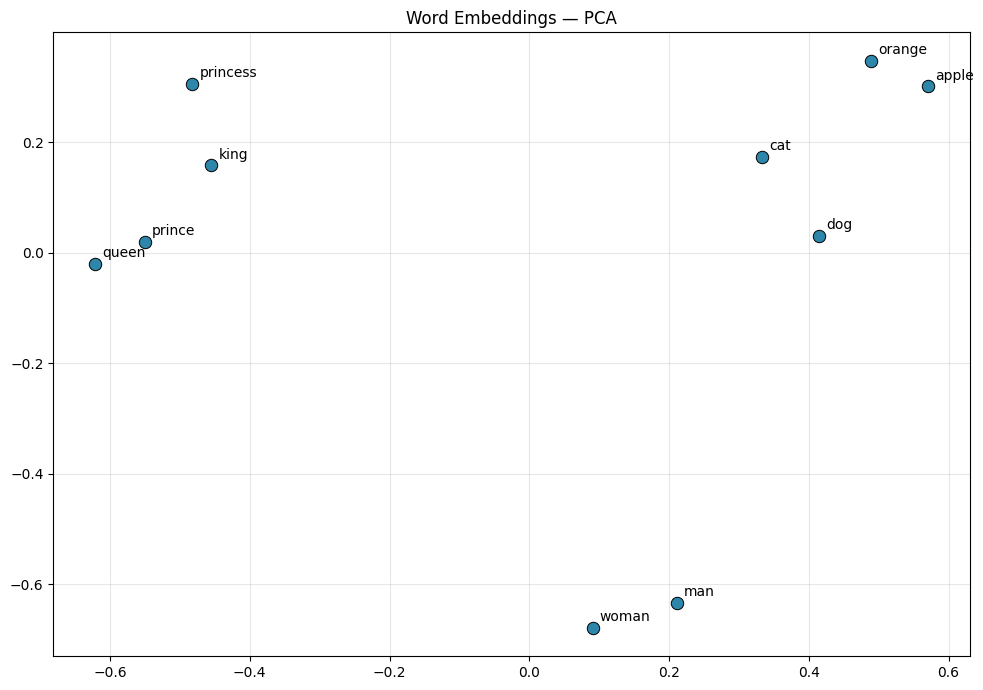

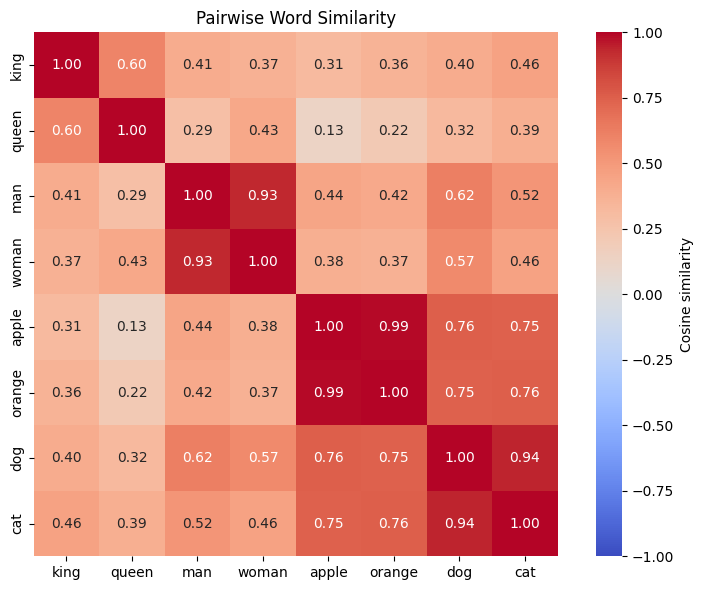

In [11]:
# 1. Embedding space (PCA)
system.plot_space(
    words=["king", "queen", "man", "woman", "prince", "princess",
           "apple", "orange", "dog", "cat"],
    method="pca",
)

# 2. Similarity heatmap
system.plot_similarity_heatmap(
    words=["king", "queen", "man", "woman", "apple", "orange", "dog", "cat"]
)

In [12]:
# Assuming groq_client from Episode 5 is available:
# groq = GroqClient(api_key=API_KEY, default_model="gpt-oss-120b")

def digital_twin_activity_advice(activity: str, system: EmbeddingSystem, groq):
    """Given an activity, use embeddings + LLM to recommend similar ones."""
    # 1. Find semantic neighbors
    try:
        neighbors = system.nearest(activity, k=5)
    except KeyError:
        return f"'{activity}' not in my vocabulary."

    # 2. Ask the LLM to explain and recommend
    return system.describe_neighborhood(activity, groq, k=5)


# Example (uncomment once groq client is wired in):
# print(digital_twin_activity_advice("king", system, groq))

In [13]:
def test_errors():
    print("Error handling tests:")
    print("-" * 50)

    cases = [
        ("dim=0",              lambda: EmbeddingSystem(dim=0)),
        ("dim='a'",            lambda: EmbeddingSystem(dim="a")),
        ("window=-1",          lambda: EmbeddingSystem(window=-1)),
        ("empty corpus",       lambda: EmbeddingSystem().fit([])),
        ("corpus with int",    lambda: EmbeddingSystem().fit(["ok", 123])),
        ("bad method",         lambda: EmbeddingSystem().fit(corpus, method="bert")),
    ]
    for name, fn in cases:
        try:
            fn()
            print(f"  ❌ {name}: no error")
        except (TypeError, ValueError) as e:
            print(f"  ✅ {name}: {type(e).__name__}: {e}")

    # Untrained queries
    fresh = EmbeddingSystem(dim=16)
    try:
        fresh.similarity("king", "queen")
    except RuntimeError as e:
        print(f"  ✅ untrained query: RuntimeError: {e}")

    # Unknown word
    try:
        system.similarity("king", "unicorn")
    except KeyError as e:
        print(f"  ✅ unknown word: KeyError: {e}")

    # Bad k
    try:
        system.nearest("king", k=0)
    except ValueError as e:
        print(f"  ✅ bad k: ValueError: {e}")

    # Bad vector shape
    try:
        system.most_similar_to_vector(np.array([1, 2, 3]))  # wrong dim
    except ValueError as e:
        print(f"  ✅ bad vector: ValueError: {e}")

    # Unknown method for visualization
    try:
        system.plot_space(words=["king", "queen"], method="umap")
    except ValueError as e:
        print(f"  ✅ bad viz method: ValueError: {e}")


test_errors()

07:06:38 | INFO    | EmbeddingSystem ready | dim=64 | window=2 | seed=42
INFO:EmbeddingSystem.138812154867360:EmbeddingSystem ready | dim=64 | window=2 | seed=42
07:06:38 | INFO    | EmbeddingSystem ready | dim=64 | window=2 | seed=42
INFO:EmbeddingSystem.138812119244752:EmbeddingSystem ready | dim=64 | window=2 | seed=42
07:06:38 | INFO    | EmbeddingSystem ready | dim=64 | window=2 | seed=42
INFO:EmbeddingSystem.138812118238896:EmbeddingSystem ready | dim=64 | window=2 | seed=42
07:06:38 | INFO    | EmbeddingSystem ready | dim=16 | window=2 | seed=42
INFO:EmbeddingSystem.138812118238896:EmbeddingSystem ready | dim=16 | window=2 | seed=42


Error handling tests:
--------------------------------------------------
  ✅ dim=0: ValueError: dim must be a positive int, got 0
  ✅ dim='a': ValueError: dim must be a positive int, got 'a'
  ✅ window=-1: ValueError: window must be a positive int, got -1
  ✅ empty corpus: ValueError: corpus cannot be empty
  ✅ corpus with int: TypeError: corpus[1] must be str, got int
  ✅ bad method: ValueError: method must be 'word2vec' or 'glove', got 'bert'
  ✅ untrained query: RuntimeError: System not trained. Call fit() first.
  ✅ unknown word: KeyError: "'unicorn' not in vocabulary"
  ✅ bad k: ValueError: k must be positive int, got 0
  ✅ bad vector: ValueError: vec must be 1-D of shape (32,), got (3,)
  ✅ bad viz method: ValueError: method must be 'pca' or 'tsne', got 'umap'


In [14]:
def verify_system():
    """Sanity assertions — should all pass."""
    s = EmbeddingSystem(dim=32, window=2, seed=42)
    s.fit(corpus, method="word2vec", epochs=40)

    # Similarity ordering
    assert s.similarity("king", "queen") > s.similarity("king", "apple"), \
        "king-queen should be more similar than king-apple"
    assert s.similarity("apple", "orange") > s.similarity("apple", "dog"), \
        "apple-orange should be more similar than apple-dog"

    # Nearest returns requested count
    assert len(s.nearest("king", k=3)) == 3

    # Analogy returns list of tuples
    result = s.analogy("king", "man", "woman", k=3)
    assert all(isinstance(w, str) and isinstance(v, float)
               for w, v in result)

    # Summary structure
    summary = s.summary()
    assert summary["trained"] is True
    assert summary["last_method"] == "word2vec"

    print("✅ All verification assertions passed")


verify_system()

07:07:05 | INFO    | EmbeddingSystem ready | dim=32 | window=2 | seed=42
INFO:EmbeddingSystem.138812156097616:EmbeddingSystem ready | dim=32 | window=2 | seed=42
07:07:05 | INFO    | Cleaned corpus: 15 → 15 sentences
INFO:EmbeddingSystem.138812156097616:Cleaned corpus: 15 → 15 sentences
07:07:05 | INFO    | Word2Vec training | pairs=98 | epochs=40
INFO:EmbeddingSystem.138812156097616:Word2Vec training | pairs=98 | epochs=40
07:07:06 | INFO    | Trained 'word2vec' | vocab=27 | 914ms
INFO:EmbeddingSystem.138812156097616:Trained 'word2vec' | vocab=27 | 914ms


✅ All verification assertions passed


In [15]:
class ActivityRecommender:
    """Use embeddings to recommend activities for the digital twin."""

    def __init__(self, system: EmbeddingSystem, groq_client):
        self.system = system
        self.groq = groq_client

    def recommend(self, recent_activity: str, n: int = 3) -> str:
        """Find semantic neighbors, then ask LLM to pick the best."""
        neighbors = self.system.nearest(recent_activity, k=10)
        candidates = ", ".join(w for w, _ in neighbors)
        prompt = (
            f"The user just did '{recent_activity}'. "
            f"Similar activities in their embedding space: {candidates}. "
            f"Recommend the top {n} activities, in order, with a one-line "
            f"reason for each."
        )
        return self.groq.chat([{"role": "user", "content": prompt}])


# Usage (once groq client is wired in):
# rec = ActivityRecommender(system, groq)
# print(rec.recommend("king", n=3))

In [16]:
# Verify everything integrates
print("Testing integration with GroqClient...")
print()

# 1. Get embedding summary
print("Embedding summary:")
for k, v in system.summary().items():
    print(f"  {k}: {v}")
print()

# 2. Try a semantic query
print("Semantic neighborhoods:")
for word in ["king", "apple", "dog"]:
    try:
        neighbors = system.nearest(word, k=3)
        nstr = ", ".join(f"{w}({s:+.2f})" for w, s in neighbors)
        print(f"  {word}: {nstr}")
    except KeyError:
        print(f"  {word}: not in vocab")
print()

# 3. (Optional) Ask the LLM to explain
# Uncomment once groq client is wired up:
# print("LLM explanation:")
# print(system.describe_neighborhood("king", groq, k=5))

Testing integration with GroqClient...

Embedding summary:
  trained: True
  last_method: word2vec
  vocab_size: 27
  dim: 32
  runs: 1
  last_duration_ms: 2016.82

Semantic neighborhoods:
  king: castle(+0.98), daughter(+0.95), princess(+0.94)
  apple: orange(+0.99), grows(+0.99), tree(+0.98)
  dog: cat(+0.94), sleeps(+0.94), runs(+0.93)



In [17]:
# Should be LOW — different categories
print("king  ↔ apple :", round(system.similarity("king", "apple"), 3))
print("king  ↔ dog   :", round(system.similarity("king", "dog"), 3))
print("apple ↔ dog   :", round(system.similarity("apple", "dog"), 3))

# Should be HIGH — same category
print()
print("king  ↔ queen :", round(system.similarity("king", "queen"), 3))
print("apple ↔ orange:", round(system.similarity("apple", "orange"), 3))
print("dog   ↔ cat   :", round(system.similarity("dog", "cat"), 3))

king  ↔ apple : 0.315
king  ↔ dog   : 0.402
apple ↔ dog   : 0.756

king  ↔ queen : 0.595
apple ↔ orange: 0.99
dog   ↔ cat   : 0.945


---
## Summary & Key Takeaways

### What We Learned:
- Word2Vec and GloVe internals
- Building embeddings from scratch
- Semantic similarity and vector operations
- Dimensionality reduction and visualization
- Using pre-trained embeddings

### Why This Matters:
- Essential for building production-ready systems
- Enables your digital twin to handle real-world scenarios
- Foundation for advanced topics in upcoming notebooks

### Next Steps:
1. Complete all exercises in this notebook
2. Integrate concepts with your digital twin project
3. Test your implementation thoroughly
4. Move on to the next notebook in Week 2

## 🏆 Challenge Project

**Build a Complete Word2Vec and GloVe internals System for Your Digital Twin**

**Requirements**:
1. Apply all concepts from this notebook
2. Handle edge cases and errors gracefully
3. Include comprehensive testing
4. Create visualizations of your results
5. Document your implementation
6. Integrate with your existing digital twin code

**Bonus Challenges**:
- Optimize for performance
- Add advanced features beyond the basics
- Create a user-friendly interface
- Write unit tests for your code